In [ ]:
import os
import geopandas as gpd
import rasterio

# === UPDATED PATHS ===
raw_base = r"F:\_____My_Thesies____\_ImpFiles"

# Spectral TIFF
data_dir = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "2.Spectral"
)
year = 2024
spectral_tif = os.path.join(data_dir, f"{year}_Opt_SR.tif")

# Reference shapefile for training/testing
ref_shp = os.path.join(
    raw_base,
    "2.Segments",
    "_Final_Reference_Combined",
    "Ref_2024.shp"
)

# Segmented OBIA polygon shapefile with band means
seg_shp = os.path.join(
    raw_base,
    "3. Feature Selection",
    "_Sentinel Data",
    "2. Divided Data",
    "6.Segmentation",
    "Seg_2024",
    "1. Opt",
    "2024_Seg_With_Mean_Opt.shp"
)

# --- 1) LOAD REFERENCE SHAPEFILE ---
print("📂 Reference Shapefile path:", ref_shp)
ref_gdf = gpd.read_file(ref_shp)
print("✅ Reference shapefile loaded")
print("Columns:", ref_gdf.columns.tolist())
print("Number of polygons:", len(ref_gdf))
print("Unique classes in 'layer':", ref_gdf["layer"].unique())

# --- 2) LOAD SEGMENTED SHAPEFILE ---
print("\n📂 Segmented Shapefile path:", seg_shp)
seg_gdf = gpd.read_file(seg_shp)
print("✅ Segmented shapefile loaded")
print("Columns:", seg_gdf.columns.tolist())
print("Number of segments:", len(seg_gdf))

📂 Reference Shapefile path: F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp
✅ Reference shapefile loaded
Columns: ['fid_1', 'Name', 'descriptio', 'layer', 'path', 'Feature_ID', 'Area', 'geometry']
Number of polygons: 206
Unique classes in 'layer': ['Wheat-polygon' 'Rice-polygon' 'Clover-polygon' 'Alfalfa-polygon'
 'Corn-polygon' 'Sugar_Beet-polygon' 'Urban-polygon' 'Plowed-polygon'
 'Phragmites-polygon' 'Degreed_Wetland_Poly-polygon' 'Tamarix-polygon'
 'Mixed_TP-polygon' 'Bare-polygon']

📂 Segmented Shapefile path: F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt.shp
✅ Segmented shapefile loaded
Columns: ['PXLVAL', '_b1_mean', '_b2_mean', '_b3_mean', '_b4_mean', '_b5_mean', '_b6_mean', '_b7_mean', '_b8_mean', '_b9_mean', '_b10_mean', '_b11_mean', '_b12_mean', '_b13_mean', '_b14_mean', '_b15_mean', '_b16_mean', '_b17_mean', '_b18_mean', '_b19_mean', '_b20_mean', '

C:\Users\mamad_js\AppData\Local\Temp\ipykernel_19304\2417091968.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("tab20", len(unique_classes))


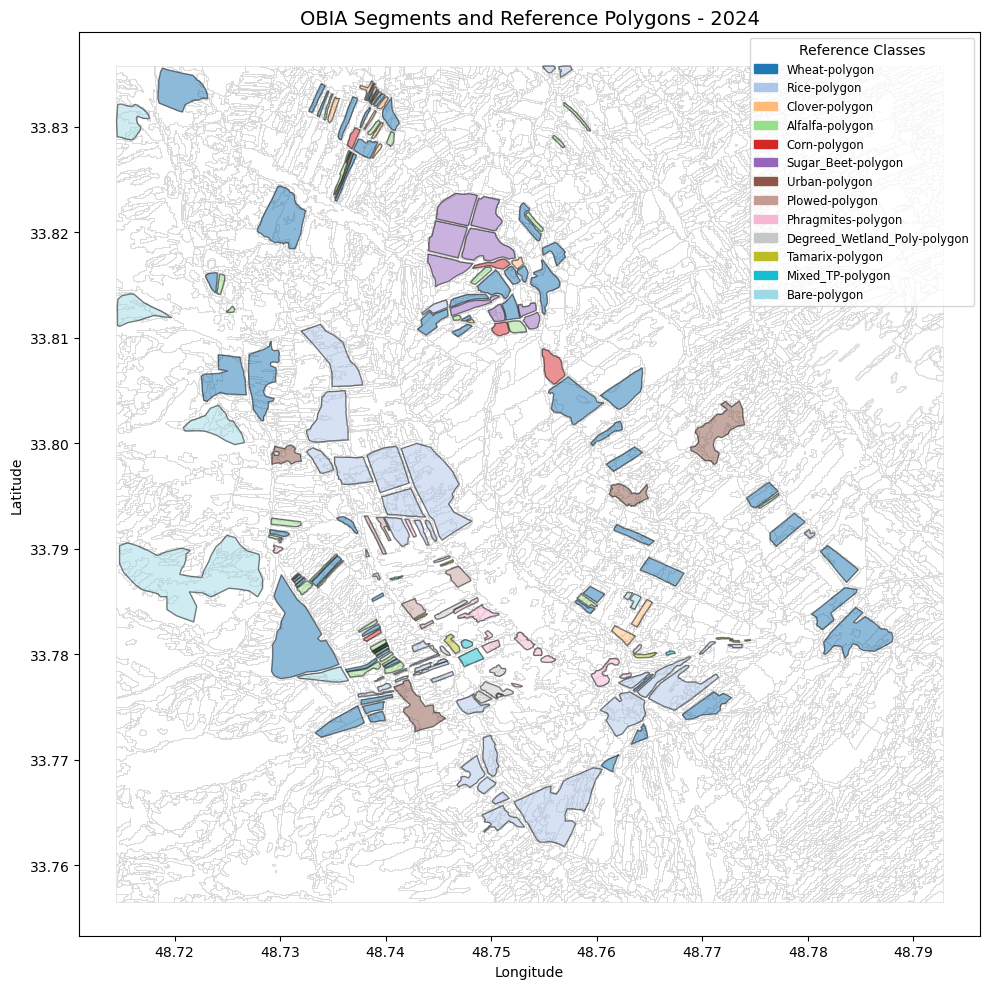

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl

# === Load shapefiles ===
ref_shp = r"F:\_____My_Thesies____\_ImpFiles\2.Segments\_Final_Reference_Combined\Ref_2024.shp"
seg_shp = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\6.Segmentation\Seg_2024\1. Opt\2024_Seg_With_Mean_Opt.shp"

gdf_ref = gpd.read_file(ref_shp)
gdf_seg = gpd.read_file(seg_shp)

# === Ensure same CRS ===
if gdf_ref.crs != gdf_seg.crs:
    gdf_seg = gdf_seg.to_crs(gdf_ref.crs)

# === Create color map for classes ===
unique_classes = gdf_ref["layer"].unique()
cmap = mpl.cm.get_cmap("tab20", len(unique_classes))
class_to_color = {cls: cmap(i) for i, cls in enumerate(unique_classes)}

# === Plotting ===
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("OBIA Segments and Reference Polygons - 2024", fontsize=14)

# Plot segments (in light gray)
gdf_seg.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=0.5, alpha=0.8)

# Plot reference polygons with class colors
for cls, color in class_to_color.items():
    gdf_ref[gdf_ref["layer"] == cls].plot(
        ax=ax,
        edgecolor="black",
        facecolor=color,
        alpha=0.5,
        linewidth=1,
        label=cls
    )

# Customize legend
handles = [mpl.patches.Patch(color=col, label=lab) for lab, col in class_to_color.items()]
ax.legend(handles=handles, title="Reference Classes", fontsize="small", loc="upper right", framealpha=0.8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.axis('equal')
plt.tight_layout()
plt.savefig('OBIA Segments and Reference Polygons - 2024.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


## Training data


In [31]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def preprocess_segmented_data(seg_gdf, ref_gdf):
    """
    Preprocess the segmented data by:
    1. Removing columns with >50% NaN values
    2. Filling remaining NaN values using temporal interpolation
    """
    
    # Make a copy to avoid modifying original
    seg_gdf = seg_gdf.copy()
    
    # ==================================================================
    # STEP 1: Remove columns with >50% NaN values
    # ==================================================================
    print("\n🔍 STEP 1: Identifying and removing columns with >50% NaN values")
    
    # Get all band columns (assuming they start with '_b')
    band_cols = [col for col in seg_gdf.columns if col.startswith('_b')]
    total_segments = len(seg_gdf)
    threshold = total_segments * 0.5  # 50% threshold
    
    cols_to_drop = []
    for col in band_cols:
        nan_count = seg_gdf[col].isna().sum()
        if nan_count > threshold:
            cols_to_drop.append(col)
            print(f"  - Column {col} has {nan_count}/{total_segments} NaN values ({(nan_count/total_segments)*100:.1f}%) - will be dropped")
    
    # Drop the identified columns
    seg_gdf = seg_gdf.drop(columns=cols_to_drop)
    remaining_bands = [col for col in seg_gdf.columns if col.startswith('_b')]
    print(f"✅ Completed. Dropped {len(cols_to_drop)} columns. Remaining {len(remaining_bands)} bands")
    
    # ==================================================================
    # STEP 2: Fill remaining NaN values using temporal interpolation
    # ==================================================================
    print("\n🔍 STEP 2: Filling remaining NaN values using temporal interpolation")
    
    # First pass: Fill with monthly mean (assuming band names contain date info)
    print("  - Filling with monthly mean values where possible...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        # Extract month from band name (assuming format like '_b202401_mean' for Jan 2024)
        try:
            month = int(col.split('_')[1][4:6])  # Extract month part
            # Find other bands from same month
            same_month_cols = [c for c in remaining_bands 
                              if c.startswith('_b') and int(c.split('_')[1][4:6]) == month]
            # Calculate monthly mean for each segment
            monthly_means = seg_gdf[same_month_cols].mean(axis=1)
            # Fill NaN with monthly mean
            seg_gdf[col] = seg_gdf[col].fillna(monthly_means)
        except:
            continue
    
    # Second pass: Fill with seasonal mean (previous, current, next month)
    print("  - Filling remaining gaps with seasonal mean (prev+current+next month)...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        # Skip if no more NaNs
        if not seg_gdf[col].isna().any():
            continue
            
        try:
            year_month = col.split('_')[1][0:6]  # Get YYYYMM part
            year = int(year_month[0:4])
            month = int(year_month[4:6])
            
            # Find bands from adjacent months
            prev_month = month - 1 if month > 1 else 12
            next_month = month + 1 if month < 12 else 1
            
            # Handle year change for December/January
            prev_year = year if month > 1 else year - 1
            next_year = year if month < 12 else year + 1
            
            # Format strings for adjacent months
            prev_col_pattern = f"_b{prev_year}{prev_month:02d}"
            next_col_pattern = f"_b{next_year}{next_month:02d}"
            
            # Find matching columns
            seasonal_cols = []
            for c in remaining_bands:
                if (c.startswith('_b') and 
                    (year_month in c or 
                     prev_col_pattern in c or 
                     next_col_pattern in c)):
                    seasonal_cols.append(c)
            
            if len(seasonal_cols) > 1:  # Need at least one other band
                seasonal_mean = seg_gdf[seasonal_cols].mean(axis=1)
                seg_gdf[col] = seg_gdf[col].fillna(seasonal_mean)
        except:
            continue
    
    # Final pass: Fill with yearly mean for any remaining NaNs
    print("  - Filling any remaining gaps with yearly mean...")
    for col in tqdm(remaining_bands, desc="Processing bands"):
        if seg_gdf[col].isna().any():
            # Calculate mean of all bands for each segment
            yearly_mean = seg_gdf[remaining_bands].mean(axis=1)
            seg_gdf[col] = seg_gdf[col].fillna(yearly_mean)
    
    # Verify no NaNs remain
    remaining_nans = seg_gdf[remaining_bands].isna().sum().sum()
    print(f"✅ Completed. Total remaining NaN values: {remaining_nans}")
    
    # ==================================================================
    # STEP 3: Prepare final dataset
    # ==================================================================
    print("\n📊 Final dataset summary:")
    print(f"- Total segments processed: {len(seg_gdf)}")
    print(f"- Total reference polygons: {len(ref_gdf)}")
    print(f"- Remaining bands: {len(remaining_bands)}")
    print("- Sample of processed data:")
    print(seg_gdf[remaining_bands[:5]].head())
    
    return seg_gdf

# Run the preprocessing
processed_seg_gdf = preprocess_segmented_data(seg_gdf, ref_gdf)


🔍 STEP 1: Identifying and removing columns with >50% NaN values
  - Column _b21_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b22_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b23_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b24_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b25_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b26_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b27_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b28_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b29_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b30_mean has 3949/6311 NaN values (62.6%) - will be dropped
  - Column _b81_mean has 3801/6311 NaN values (60.2%) - will be dropped
  - Column _b82_mean has 3801/6311 NaN values (60.2%) - will be dropped
  - Column _b83_mean has 3801/6311 NaN values (60.2%) - will be dropped

Processing bands: 100%|██████████| 600/600 [00:00<00:00, 199112.46it/s]


  - Filling remaining gaps with seasonal mean (prev+current+next month)...


Processing bands: 100%|██████████| 600/600 [00:00<00:00, 5055.31it/s]


  - Filling any remaining gaps with yearly mean...


Processing bands: 100%|██████████| 600/600 [00:13<00:00, 44.76it/s] 

✅ Completed. Total remaining NaN values: 0

📊 Final dataset summary:
- Total segments processed: 6311
- Total reference polygons: 206
- Remaining bands: 600
- Sample of processed data:
     _b1_mean    _b2_mean     _b3_mean     _b4_mean     _b5_mean
0  755.000000  980.000000  1230.000000  1507.000000  1606.000000
1  682.666667  966.666667  1017.666667  1333.000000  2051.000000
2  601.250000  811.500000   976.500000  1503.000000  2158.000000
3  750.600000  941.200000  1118.400000  1330.600000  1569.200000
4  731.000000  999.250000  1131.166667  1446.833333  1864.666667


### PeProcess Data

In [32]:
import numpy as np
import geopandas as gpd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================================
# STEP 1: Prepare Training Data (Intersect segments with reference)
# ========================================================
print("\n🔍 STEP 1: Preparing training data by intersecting segments with reference polygons")

# Spatial join between segments and reference polygons
joined_gdf = gpd.sjoin(processed_seg_gdf, ref_gdf, how='inner', predicate='intersects')

# Get band columns (all columns starting with '_b')
band_cols = [col for col in processed_seg_gdf.columns if col.startswith('_b')]
X = joined_gdf[band_cols].values
y = joined_gdf['layer'].values  # Your class labels

# Encode class labels to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"✅ Training data prepared:")
print(f"- Total labeled segments: {len(joined_gdf)}")
print(f"- Number of features: {X.shape[1]}")
print(f"- Classes: {label_encoder.classes_}")

# ========================================================
# STEP 2: Train-Test Split (70-30)
# ========================================================
print("\n🔍 STEP 2: Splitting data into training (70%) and test (30%) sets")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"✅ Data split completed:")
print(f"- Training samples: {X_train.shape[0]}")
print(f"- Test samples: {X_test.shape[0]}")

# ========================================================
# STEP 3: Train Random Forest with 5-Fold CV
# ========================================================
print("\n🔍 STEP 3: Training Random Forest with 5-fold cross-validation")

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

# 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=kf, scoring='accuracy')

print("\n📊 Cross-Validation Results:")
print(f"- Fold accuracies: {cv_scores}")
print(f"- Mean CV accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

# Train final model on full training set
rf.fit(X_train, y_train)
print("\n✅ Model trained on full training set")


🔍 STEP 1: Preparing training data by intersecting segments with reference polygons
✅ Training data prepared:
- Total labeled segments: 1234
- Number of features: 600
- Classes: ['Alfalfa-polygon' 'Bare-polygon' 'Clover-polygon' 'Corn-polygon'
 'Degreed_Wetland_Poly-polygon' 'Mixed_TP-polygon' 'Phragmites-polygon'
 'Plowed-polygon' 'Rice-polygon' 'Sugar_Beet-polygon' 'Tamarix-polygon'
 'Urban-polygon' 'Wheat-polygon']

🔍 STEP 2: Splitting data into training (70%) and test (30%) sets
✅ Data split completed:
- Training samples: 863
- Test samples: 371

🔍 STEP 3: Training Random Forest with 5-fold cross-validation


c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\tools\sjoin.py:274: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_reset.reset_index(inplace=True)



📊 Cross-Validation Results:
- Fold accuracies: [0.64739884 0.64739884 0.67052023 0.63953488 0.61627907]
- Mean CV accuracy: 0.6442 ± 0.0174

✅ Model trained on full training set



🔍 STEP 4: Comprehensive evaluation on test set

📊 Comprehensive Test Set Performance:

Overall Metrics:
- Accuracy: 0.6092
- Balanced Accuracy: 0.3960
- Cohen's Kappa: 0.5015
- Macro F1-Score: 0.4020

Class-wise Metrics:
                       Class  Precision   Recall  F1-Score  Support
             Alfalfa-polygon   0.266667 0.222222  0.242424       36
                Bare-polygon   0.882353 0.714286  0.789474       21
              Clover-polygon   0.187500 0.157895  0.171429       19
                Corn-polygon   0.000000 0.000000  0.000000        8
Degreed_Wetland_Poly-polygon   0.400000 0.333333  0.363636        6
            Mixed_TP-polygon   0.000000 0.000000  0.000000        4
          Phragmites-polygon   0.526316 0.666667  0.588235       15
              Plowed-polygon   0.200000 0.200000  0.200000        5
                Rice-polygon   0.820755 0.836538  0.828571      104
          Sugar_Beet-polygon   0.833333 0.714286  0.769231       14
             Tamarix-polygon  

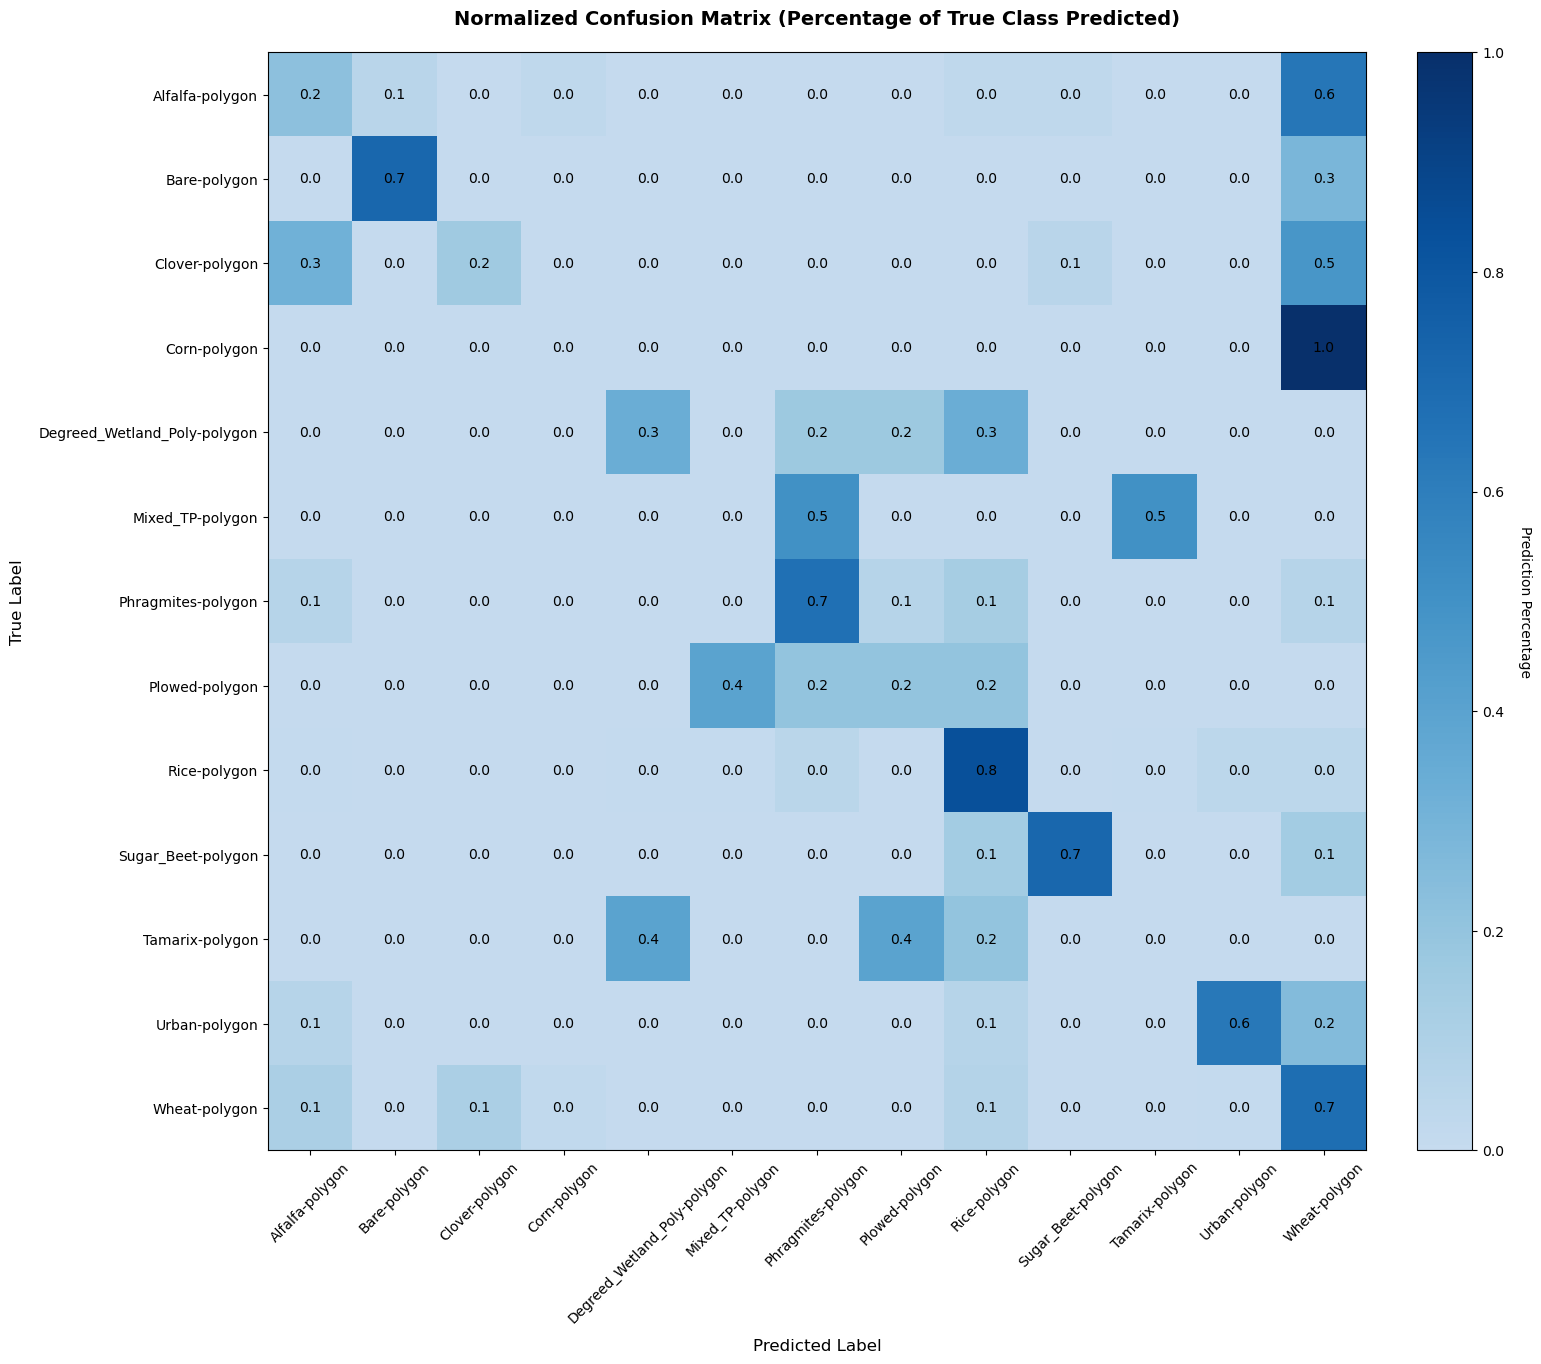

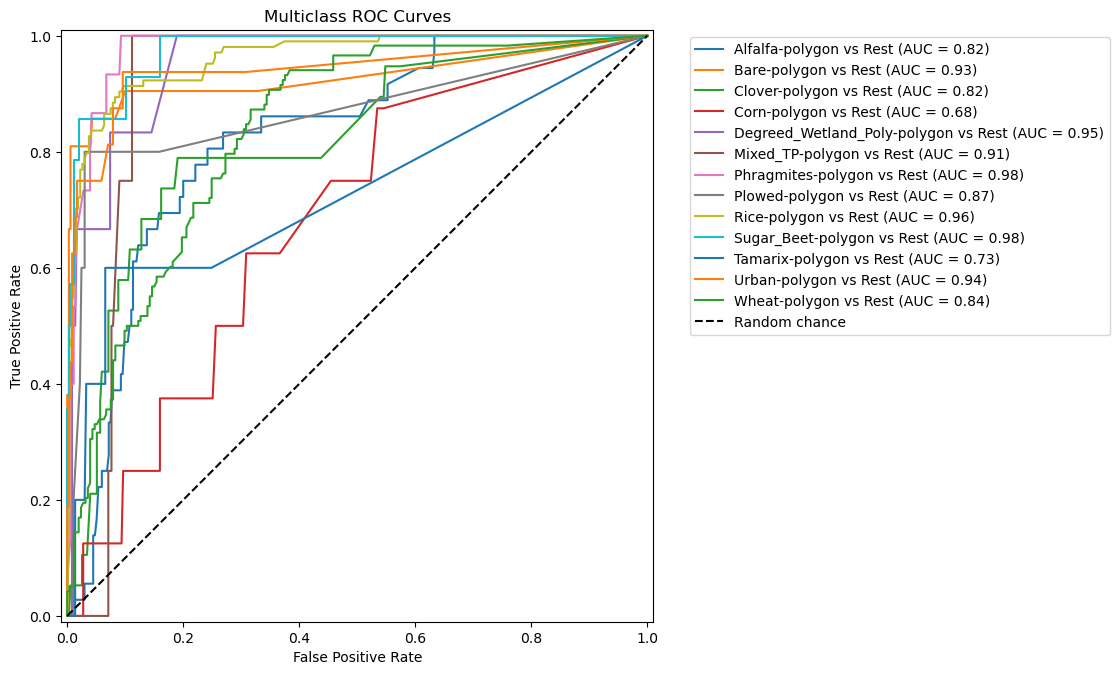

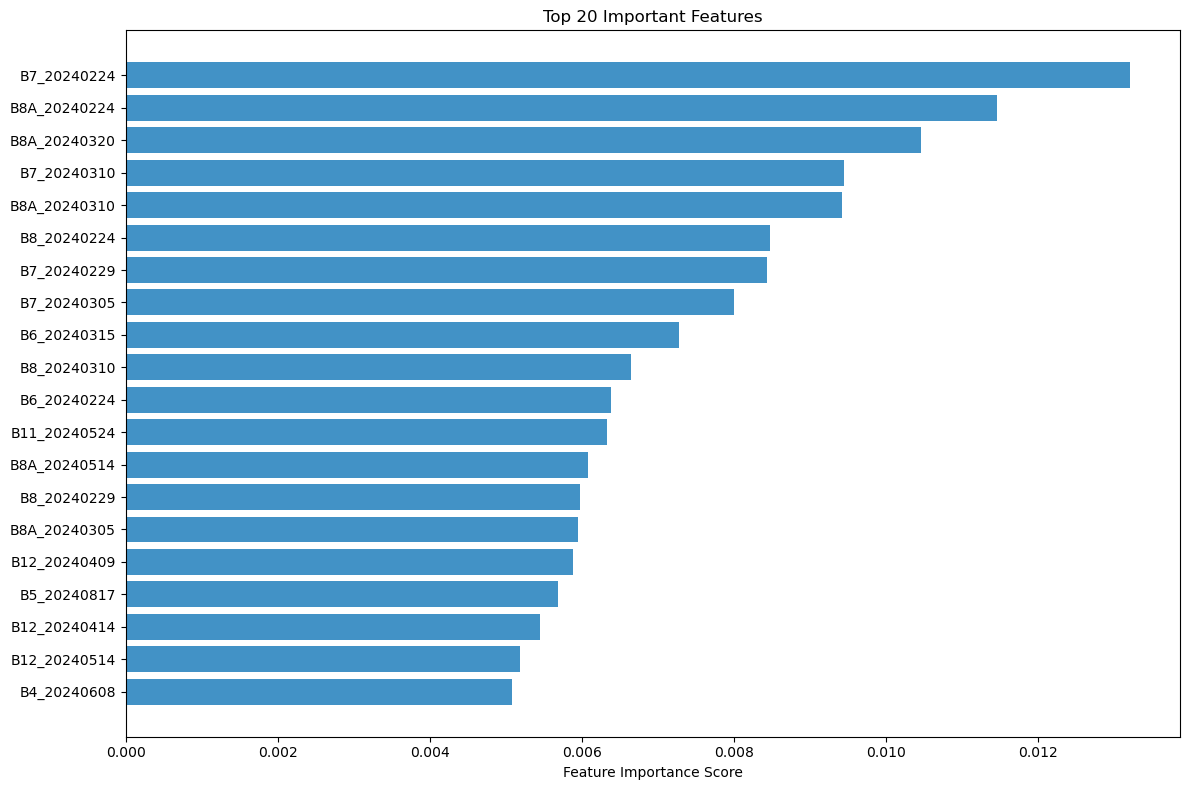

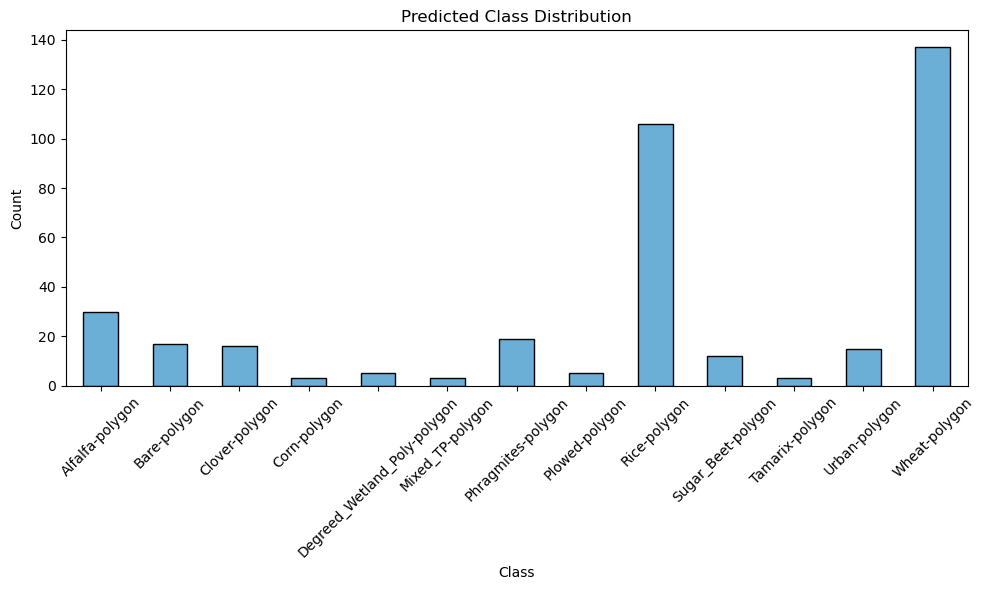

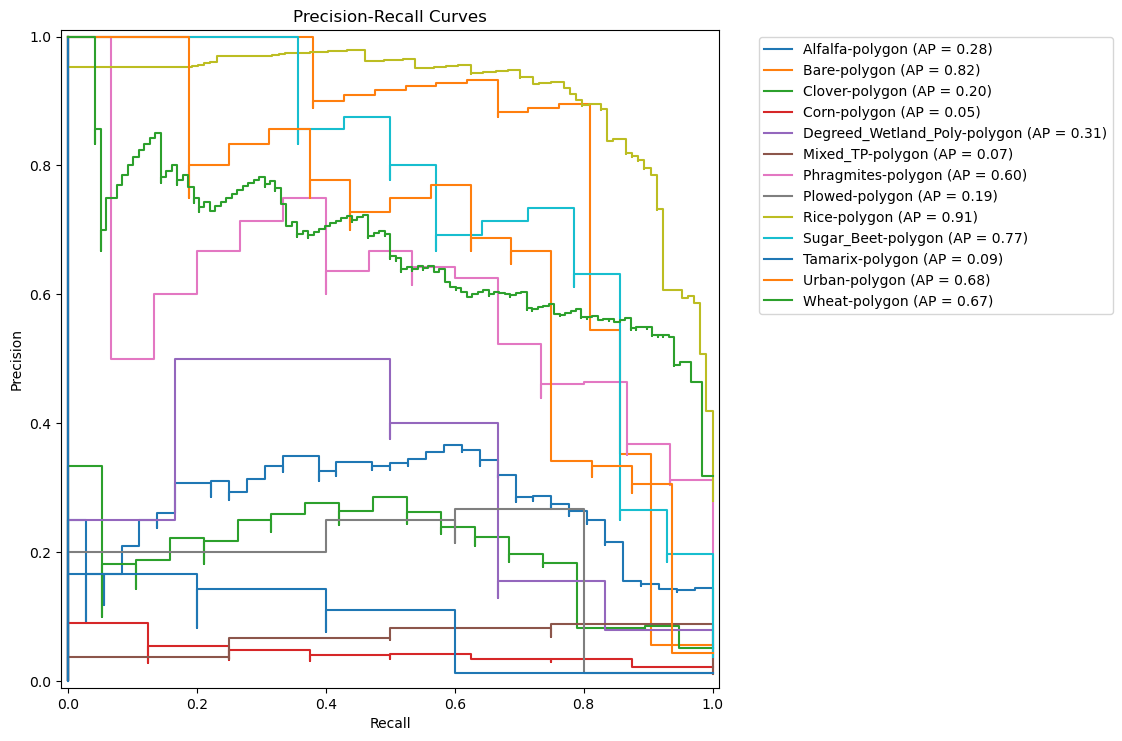


📊 Additional Evaluation Metrics:

One-vs-Rest ROC AUC Scores:
- Alfalfa-polygon: 0.8228
- Bare-polygon: 0.9288
- Clover-polygon: 0.8186
- Corn-polygon: 0.6808
- Degreed_Wetland_Poly-polygon: 0.9532
- Mixed_TP-polygon: 0.9142
- Phragmites-polygon: 0.9774
- Plowed-polygon: 0.8680
- Rice-polygon: 0.9622
- Sugar_Beet-polygon: 0.9768
- Tamarix-polygon: 0.7281
- Urban-polygon: 0.9398
- Wheat-polygon: 0.8365
- Macro Average: 0.8775

Enhanced Classification Report:
                              precision    recall  f1-score   support

             Alfalfa-polygon     0.2667    0.2222    0.2424        36
                Bare-polygon     0.8824    0.7143    0.7895        21
              Clover-polygon     0.1875    0.1579    0.1714        19
                Corn-polygon     0.0000    0.0000    0.0000         8
Degreed_Wetland_Poly-polygon     0.4000    0.3333    0.3636         6
            Mixed_TP-polygon     0.0000    0.0000    0.0000         4
          Phragmites-polygon     0.5263    0.6

In [33]:
# ========================================================
# STEP 4: Enhanced Evaluation on Test Set
# ========================================================
print("\n🔍 STEP 4: Comprehensive evaluation on test set")

from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            balanced_accuracy_score, cohen_kappa_score,
                            roc_auc_score, classification_report, 
                            confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.colors as mcolors

# Generate predictions
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

# ====================
# 1. Numerical Metrics
# ====================
print("\n📊 Comprehensive Test Set Performance:")

# Basic metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Class-wise metrics
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': np.bincount(y_test)
})

# Print overall metrics
print(f"\nOverall Metrics:")
print(f"- Accuracy: {accuracy:.4f}")
print(f"- Balanced Accuracy: {balanced_acc:.4f}")
print(f"- Cohen's Kappa: {kappa:.4f}")
print(f"- Macro F1-Score: {macro_f1:.4f}")

# Print detailed class metrics
print("\nClass-wise Metrics:")
print(metrics_df.to_string(index=False))

# ====================
# 2. Visualizations
# ====================

# Custom color palette
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom', ['#f7fbff', '#4292c6', '#08306b'], N=256)

# 2.1 Enhanced Confusion Matrix
# Enhanced Confusion Matrix with Better Layout
plt.figure(figsize=(16, 14))  # Slightly smaller but more balanced size

# Create custom blue color gradient
cmap = plt.cm.Blues(np.linspace(0, 1, 256))
cmap = mcolors.ListedColormap(cmap[64:, :-1])  # Skip the very lightest blues

disp = ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=label_encoder.classes_,
    cmap=cmap,
    normalize='true',
    values_format='.1f',  # Just one decimal place
    xticks_rotation=45,
    ax=plt.gca(),
    colorbar=False  # We'll add our own
)

# Improve text visibility by setting font color based on cell darkness
threshold = 0.5  # Adjust this if needed
for text in disp.text_.ravel():
    color = 'white' if float(text.get_text().strip('%'))/100 > threshold else 'black'
    text.set_color(color)
    text.set_fontsize(10)  # Slightly smaller font

plt.title('Normalized Confusion Matrix (Percentage of True Class Predicted)', 
          fontsize=14, pad=20, weight='bold')
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.ylabel('True Label', fontsize=12, labelpad=10)

# Add colorbar with percentage labels
cbar = plt.colorbar(disp.im_, fraction=0.046, pad=0.04)
cbar.set_label('Prediction Percentage', rotation=270, labelpad=20)

# Adjust layout to prevent label cutoff
plt.tight_layout(pad=2.0)

# Save with high resolution
plt.savefig('Confusion_Matrix.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# 2.2 ROC Curves (for multiclass)
try:
    from sklearn.metrics import RocCurveDisplay
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(label_encoder.classes_):
        RocCurveDisplay.from_predictions(
            y_test == i,
            y_proba[:, i],
            name=f"{class_name} vs Rest",
            ax=plt.gca()
        )
    plt.plot([0, 1], [0, 1], 'k--', label="Random chance")
    plt.title('Multiclass ROC Curves')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('Multiclass ROC Curves.png', dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
except Exception as e:
    print(f"\n⚠️ Could not plot ROC curves: {str(e)}")

# 2.3 Feature Importance Plot (Top 20)
plt.figure(figsize=(12, 8))
sorted_idx = rf.feature_importances_.argsort()[::-1][:20]
plt.barh(
    np.array([band_name_mapping.get(band_cols[i], band_cols[i]) for i in sorted_idx]),
    rf.feature_importances_[sorted_idx],
    color='#4292c6'
)
plt.title('Top 20 Important Features')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('Top 20 Important Features.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# 2.4 Class Prediction Distribution
plt.figure(figsize=(10, 6))
pd.Series(y_pred).value_counts().sort_index().plot(
    kind='bar', 
    color='#6baed6',
    edgecolor='black'
)
plt.xticks(
    ticks=range(len(label_encoder.classes_)),
    labels=label_encoder.classes_,
    rotation=45
)
plt.title('Predicted Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('Predicted Class Distribution.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# 2.5 Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(label_encoder.classes_):
    PrecisionRecallDisplay.from_predictions(
        y_test == i,
        y_proba[:, i],
        name=f"{class_name}",
        ax=plt.gca()
    )
plt.title('Precision-Recall Curves')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Precision-Recall Curves.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# ====================
# 3. Additional Metrics
# ====================
print("\n📊 Additional Evaluation Metrics:")

# Per-class ROC AUC (One-vs-Rest)
try:
    roc_auc = roc_auc_score(
        y_test, 
        y_proba, 
        multi_class='ovr', 
        average=None
    )
    print("\nOne-vs-Rest ROC AUC Scores:")
    for class_name, score in zip(label_encoder.classes_, roc_auc):
        print(f"- {class_name}: {score:.4f}")
    print(f"- Macro Average: {np.mean(roc_auc):.4f}")
except Exception as e:
    print(f"\n⚠️ Could not calculate ROC AUC: {str(e)}")

# Classification report with additional metrics
print("\nEnhanced Classification Report:")
print(classification_report(
    y_test, 
    y_pred, 
    target_names=label_encoder.classes_,
    digits=4
))


🔍 STEP 5: Predicting classes for all segments
Predicting probabilities...


c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\geodataframe.py:1819: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, wh


✅ Prediction completed for all segments
- First 5 predictions: ['Rice-polygon' 'Wheat-polygon' 'Wheat-polygon' 'Wheat-polygon'
 'Wheat-polygon']
- Class distribution in predictions:
pred_class
Wheat-polygon                   3716
Rice-polygon                    1309
Alfalfa-polygon                  461
Bare-polygon                     303
Urban-polygon                    214
Phragmites-polygon               107
Clover-polygon                    93
Sugar_Beet-polygon                62
Tamarix-polygon                   10
Degreed_Wetland_Poly-polygon      10
Corn-polygon                       9
Plowed-polygon                     9
Mixed_TP-polygon                   8
Name: count, dtype: int64

🔍 STEP 6: Visualizing and comparing prediction results


c:\Users\mamad_js\anaconda3\envs\rs\Lib\site-packages\geopandas\tools\sjoin.py:274: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_reset.reset_index(inplace=True)


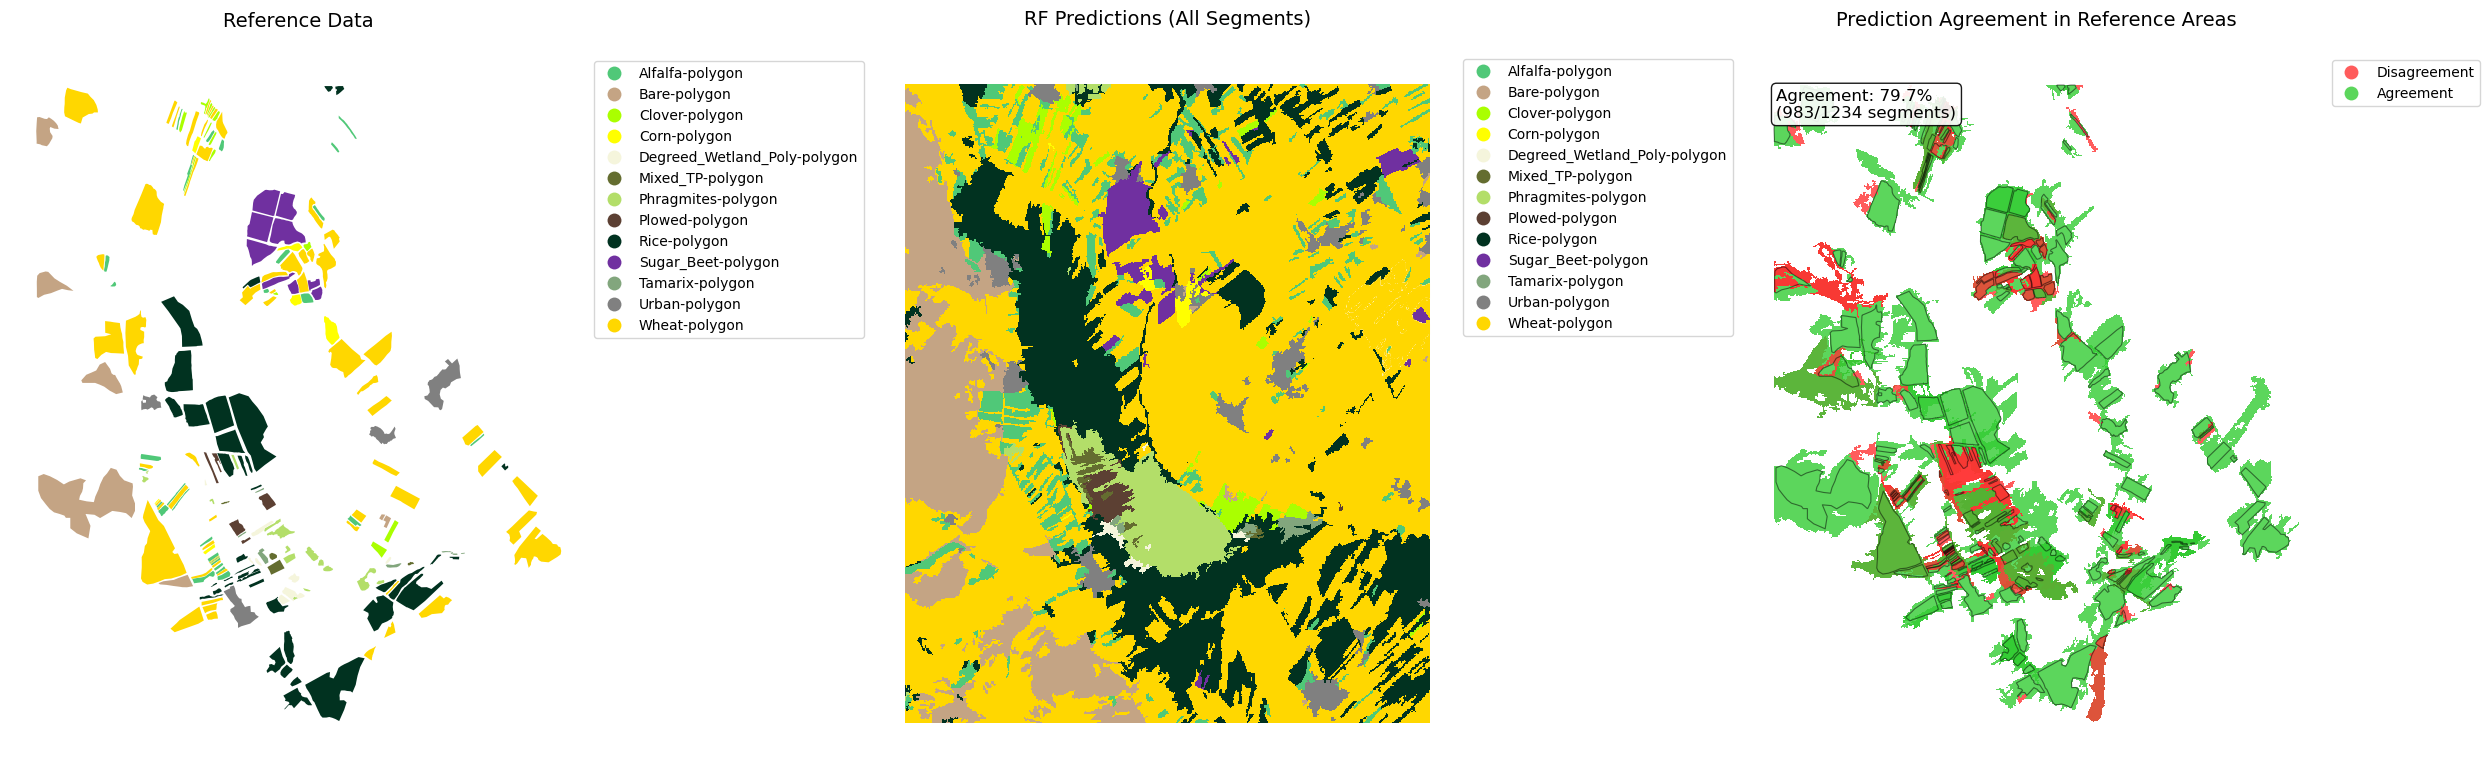


🔍 Class-wise Accuracy Analysis


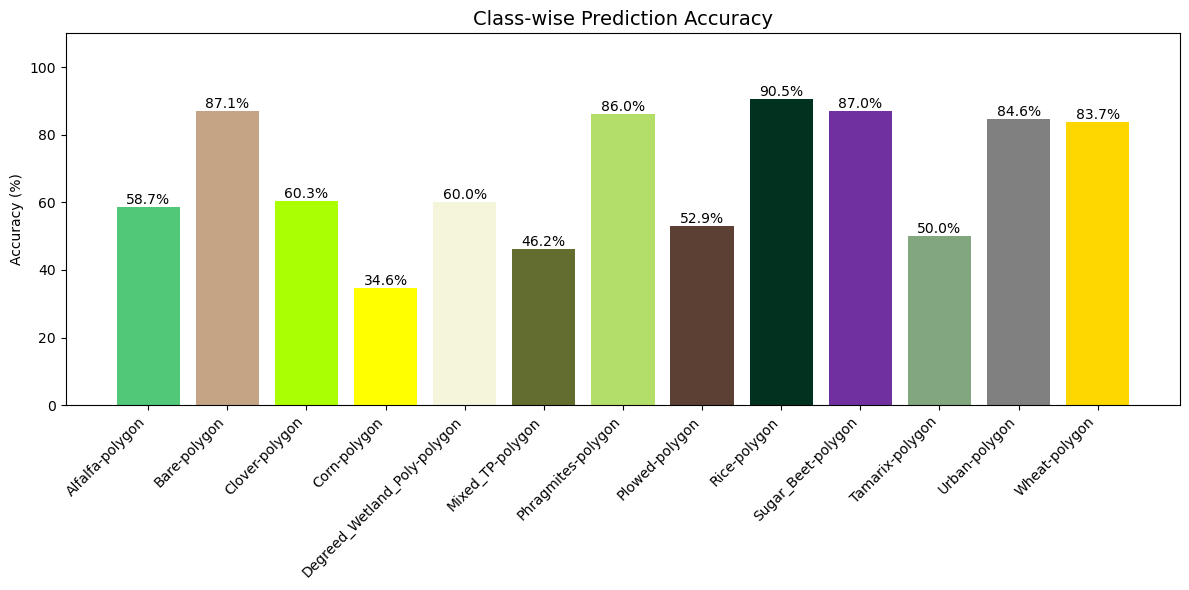


Class-wise Accuracy Metrics (matches confusion matrix order):
                       Class  Correct  Total  Accuracy
             Alfalfa-polygon       71    121 58.677686
                Bare-polygon       61     70 87.142857
              Clover-polygon       38     63 60.317460
                Corn-polygon        9     26 34.615385
Degreed_Wetland_Poly-polygon       12     20 60.000000
            Mixed_TP-polygon        6     13 46.153846
          Phragmites-polygon       43     50 86.000000
              Plowed-polygon        9     17 52.941176
                Rice-polygon      313    346 90.462428
          Sugar_Beet-polygon       40     46 86.956522
             Tamarix-polygon        9     18 50.000000
               Urban-polygon       44     52 84.615385
               Wheat-polygon      328    392 83.673469


In [34]:
# ========================================================
# STEP 5: Predict on All Segments
# ========================================================
print("\n🔍 STEP 5: Predicting classes for all segments")

# Prepare full dataset (all segments)
X_full = processed_seg_gdf[band_cols].values

# Predict probabilities and classes
print("Predicting probabilities...")
y_full_proba = rf.predict_proba(X_full)
y_full_pred = rf.predict(X_full)

# Convert back to class labels
y_full_labels = label_encoder.inverse_transform(y_full_pred)

# Add predictions to the GeoDataFrame
processed_seg_gdf['pred_class'] = y_full_labels
for i, class_name in enumerate(label_encoder.classes_):
    processed_seg_gdf[f'prob_{class_name}'] = y_full_proba[:, i]

print("\n✅ Prediction completed for all segments")
print(f"- First 5 predictions: {y_full_labels[:5]}")
print(f"- Class distribution in predictions:")
print(processed_seg_gdf['pred_class'].value_counts())

# ========================================================
# STEP 6: Enhanced Results Visualization with Focused Overlay
# ========================================================
print("\n🔍 STEP 6: Visualizing and comparing prediction results")

# Create figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 10))

# Custom color palette matching the classes in your confusion matrix
class_palette = {
    'Alfalfa-polygon': '#50C878',
    'Bare-polygon': '#C4A484',
    'Clover-polygon': '#AAFF00',
    'Corn-polygon': '#FFFF00',
    'Degreed_Wetland_Poly-polygon': '#F5F5DC',
    'Mixed_TP-polygon': '#646D30',
    'Phragmites-polygon': '#b3de69',
    'Plowed-polygon': '#5C4033',
    'Rice-polygon': '#013220',
    'Sugar_Beet-polygon': '#7030A0',
    'Tamarix-polygon': '#82A67D',
    'Urban-polygon': '#808080',
    'Wheat-polygon': '#FFD700'
}

# --- Plot 1: Reference Data ---
ref_gdf.plot(column='layer', ax=ax1, 
            categorical=True,
            cmap=ListedColormap([class_palette[cls] for cls in class_palette]),
            legend=True,
            legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
ax1.set_title('Reference Data', fontsize=14, pad=20)
ax1.set_axis_off()

# --- Plot 2: Predictions (All Segments) ---
processed_seg_gdf.plot(column='pred_class', ax=ax2, 
                     categorical=True,
                     cmap=ListedColormap([class_palette[cls] for cls in class_palette]),
                     legend=True,
                     legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)})
ax2.set_title('RF Predictions (All Segments)', fontsize=14, pad=20)
ax2.set_axis_off()

# --- Plot 3: Focused Agreement/Disagreement ---
# Calculate IoU for each segment
joined = gpd.sjoin(processed_seg_gdf, ref_gdf, how='inner', predicate='intersects')

# Create agreement column (True where prediction matches reference)
joined['agreement'] = joined['pred_class'] == joined['layer']

# Convert to categorical for better plotting
joined['agreement'] = joined['agreement'].astype('category')

# Create a custom colormap for agreement
agreement_cmap = ListedColormap(['#ff3333', '#33cc33'])  # Red=disagree, Green=agree

# Plot only segments that intersect with reference polygons
joined.plot(column='agreement', 
           ax=ax3, 
           categorical=True,
           cmap=agreement_cmap,
           alpha=0.8,
           legend=True,
           legend_kwds={'labels': ['Disagreement', 'Agreement'], 'loc': 'upper left', 'bbox_to_anchor': (1, 1)})

# Add reference boundaries for context
ref_gdf.boundary.plot(ax=ax3, color='black', linewidth=0.8, alpha=0.5)

# Calculate and display accuracy metrics
total_segments = len(joined)
correct_segments = joined['agreement'].cat.codes.sum()  # True=1, False=0
agreement_perc = (correct_segments / total_segments) * 100

# Add text box with metrics
textstr = f"Agreement: {agreement_perc:.1f}%\n({correct_segments}/{total_segments} segments)"
props = dict(boxstyle='round', facecolor='white', alpha=0.9)
ax3.text(0.05, 0.95, textstr, transform=ax3.transAxes,
        verticalalignment='top', bbox=props, fontsize=12)

ax3.set_title('Prediction Agreement in Reference Areas', fontsize=14, pad=20)
ax3.set_axis_off()

plt.tight_layout()
plt.savefig('prediction_agreement.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# --- Additional Visualization: Class-wise Accuracy ---
print("\n🔍 Class-wise Accuracy Analysis")

# Calculate class-specific accuracy
class_accuracy = []
for cls in sorted(ref_gdf['layer'].unique()):
    # Get reference polygons of this class
    ref_mask = joined['layer'] == cls
    if ref_mask.sum() > 0:  # Only process if class exists in reference
        class_correct = (joined[ref_mask]['pred_class'] == cls).sum()
        class_total = ref_mask.sum()
        class_accuracy.append({
            'Class': cls,
            'Correct': class_correct,
            'Total': class_total,
            'Accuracy': (class_correct / class_total) * 100
        })

# Create dataframe and sort by class name to match confusion matrix
accuracy_df = pd.DataFrame(class_accuracy).sort_values('Class')

# Plot class accuracy with matching colors
plt.figure(figsize=(12, 6))
bars = plt.bar(accuracy_df['Class'], accuracy_df['Accuracy'], 
              color=[class_palette[cls] for cls in accuracy_df['Class']])
plt.title('Class-wise Prediction Accuracy', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 110)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%',
             ha='center', va='bottom')

plt.tight_layout()
plt.savefig('Class-wise Prediction Accuracy.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()

# Print class accuracy table
print("\nClass-wise Accuracy Metrics (matches confusion matrix order):")
print(accuracy_df.to_string(index=False))


🔍 STEP 7: Analyzing feature importance with real band names
- Found 730 optical bands and 122 SAR bands in names file
- Mapped 600 optical bands to real names

Top 20 Most Important Features:
1. B7_20240224: 0.0132
2. B8A_20240224: 0.0115
3. B8A_20240320: 0.0105
4. B7_20240310: 0.0095
5. B8A_20240310: 0.0094
6. B8_20240224: 0.0085
7. B7_20240229: 0.0084
8. B7_20240305: 0.0080
9. B6_20240315: 0.0073
10. B8_20240310: 0.0066
11. B6_20240224: 0.0064
12. B11_20240524: 0.0063
13. B8A_20240514: 0.0061
14. B8_20240229: 0.0060
15. B8A_20240305: 0.0059
16. B12_20240409: 0.0059
17. B5_20240817: 0.0057
18. B12_20240414: 0.0055
19. B12_20240514: 0.0052
20. B4_20240608: 0.0051


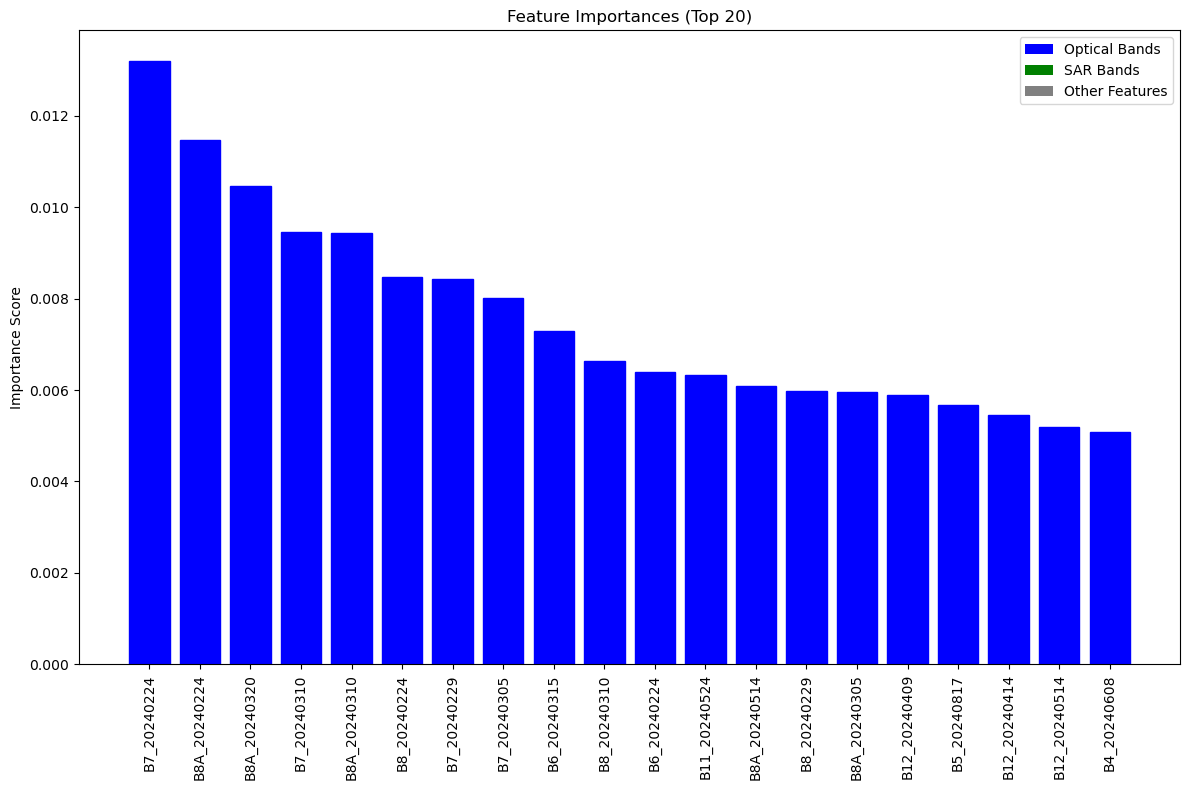

⚠️ No optical bands with parsable dates found


In [35]:
# ========================================================
# STEP 7: Feature Importance Analysis with Real Band Names
# ========================================================
print("\n🔍 STEP 7: Analyzing feature importance with real band names")

# Load the band names from your file
band_names_file = r"F:\_____My_Thesies____\_ImpFiles\3. Feature Selection\_Sentinel Data\2. Divided Data\_Bands_Names\2024_SR Bands Names.txt"
with open(band_names_file, 'r') as f:
    all_band_names = [line.strip() for line in f.readlines()]

# Separate optical and SAR bands
optical_band_names = [name for name in all_band_names if name.startswith('B')]  # Optical bands start with B
sar_band_names = [name for name in all_band_names if name.startswith(('VV','VH'))]  # SAR bands

print(f"- Found {len(optical_band_names)} optical bands and {len(sar_band_names)} SAR bands in names file")

# Create mapping only for optical bands
band_name_mapping = {}
used_optical_bands = 0

for col in band_cols:
    # Extract band number (assuming format '_b1_mean' → '1')
    try:
        band_num = int(col.split('_')[1][1:])
        # Check if we have this optical band in our names list
        if used_optical_bands < len(optical_band_names):
            band_name_mapping[col] = optical_band_names[used_optical_bands]
            used_optical_bands += 1
        else:
            band_name_mapping[col] = f"Optical_Band_{band_num}"
    except:
        # Handle non-optical bands or unexpected formats
        band_name_mapping[col] = col

print(f"- Mapped {used_optical_bands} optical bands to real names")

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Print top 20 most important features with real names
print("\nTop 20 Most Important Features:")
for i in range(20):
    band_col = band_cols[indices[i]]
    real_name = band_name_mapping.get(band_col, band_col)
    print(f"{i+1}. {real_name}: {importances[indices[i]]:.4f}")

# Plot feature importances with real names
plt.figure(figsize=(12, 8))
plt.title("Feature Importances (Top 20)")
bars = plt.bar(range(20), importances[indices[:20]], align='center')

# Color bars by band type (optical/SAR/other)
for i, bar in enumerate(bars):
    band_col = band_cols[indices[i]]
    real_name = band_name_mapping.get(band_col, band_col)
    if real_name.startswith('B'):
        bar.set_color('blue')  # Optical bands in blue
    elif real_name.startswith(('VV','VH')):
        bar.set_color('green')  # SAR bands in green
    else:
        bar.set_color('gray')  # Others in gray

plt.xticks(range(20), [band_name_mapping.get(band_cols[i], band_cols[i]) for i in indices[:20]], rotation=90)
plt.ylabel("Importance Score")
plt.tight_layout()

# Add legend for band types
legend_elements = [
    plt.Rectangle((0,0),1,1,fc='blue', label='Optical Bands'),
    plt.Rectangle((0,0),1,1,fc='green', label='SAR Bands'),
    plt.Rectangle((0,0),1,1,fc='gray', label='Other Features')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.show()

# Additional: Temporal pattern for optical bands only
try:
    # Extract dates from optical band names (format like 'B20240315')
    optical_dates = []
    optical_importances = []
    for col, imp in zip(band_cols, importances):
        real_name = band_name_mapping.get(col, col)
        if real_name.startswith('B'):
            try:
                date_str = real_name[1:9]  # Extract YYYYMMDD
                optical_dates.append(pd.to_datetime(date_str, format='%Y%m%d'))
                optical_importances.append(imp)
            except:
                continue
    
    if len(optical_dates) > 0:
        # Create DataFrame for temporal analysis
        temporal_df = pd.DataFrame({
            'Date': optical_dates,
            'Importance': optical_importances
        }).sort_values('Date')
        
        # Plot importance over time
        plt.figure(figsize=(15, 5))
        plt.plot(temporal_df['Date'], temporal_df['Importance'], 'o-', color='cyan')
        plt.title('Optical Band Importance Over Time')
        plt.xlabel('Date')
        plt.ylabel('Importance')
        plt.grid(True)
        plt.legend([line1, line2, line3], ['label1', 'label2', 'label3'])
        plt.tight_layout()
        plt.savefig('Optical Band Importance Over Time.png', dpi=600, bbox_inches='tight', facecolor='white')
        plt.show()
    else:
        print("⚠️ No optical bands with parsable dates found")
except Exception as e:
    print(f"\n⚠️ Could not plot temporal pattern: {str(e)}")